# Exercise set for Hands-On \#1

## Ordinary Differential Equations

### Exercise #1: Try to solve the more general SEIRD ODE system

The SEIRD model generalise the SIR model by adding the *exposed* $E$ population, the *recovered* $R$ population and the *dead* $D$ population:

\begin{align}
  \frac{dS}{dt} &= - \beta \, I S \,, \\
  \frac{dE}{dt} &= + \beta \, I S - \kappa  E\,, \\
  \frac{dI}{dt} &= + \kappa  E  - (\gamma + \mu) I\,, \\
  \frac{dR}{dt} &= + \gamma I\,, \\
  \frac{dD}{dt} &= + \mu I\,, \\
\end{align}

where $\beta$ is the *transmission  rate*, $\kappa$ is the *exposed to infectious* rate, $\gamma$ is the *recovery rate*, and $\mu$ is the *death rate*.

-------
https://como-dtc-collaboration.github.io/como-models/articles/SEIRD.html

#### Solution: 

It is easy to see that we can reparametrise the ODE system with more interpretable parameters:

\begin{align}
  \frac{dS}{dt} &= - \frac{R_0}{T_I} \, I S \,, \\
  \frac{dE}{dt} &= + \frac{R_0}{T_I} \, I S - \frac{1}{T_L} E \,, \\
  \frac{dI}{dt} &= + \frac{1}{T_L} E - \frac{1}{T_I} I \,, \\
  \frac{dR}{dt} &= + \frac{1 - CFR}{T_I} I \,, \\
  \frac{dD}{dt} &= + \frac{\mathrm{CFR}}{T_I} I \,, \\
\end{align}

where 

- $R_0\equiv \beta/(\gamma + \mu)$ is the *basic reproduction number* ;
- $T_L \equiv 1/\kappa$ is the *mean latent period*;
- $T_I \equiv 1/(\gamma +\mu)$ is the  *mean infectious period*;
- $\mathrm{CFR} \equiv \mu/(\gamma +\mu)$ is the *Case Fatality Ratio*.

In [3]:
from sympy import symbols, lambdify, Function
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
# the parameter
t = symbols('t')
# Create symbols S, I, R
S = Function('S')(t)
E = Function('E')(t)
I = Function('I')(t)
R = Function('R')(t)
D = Function('D')(t)
# Now the free Interpretable parameters
R0, T_L, T_I, CFR = symbols('R0 T_L T_I CFR')   # R0 = basic reproduction number
# Derived rates
beta   = R0 / T_I
kappa  = 1 / T_L
gamma  = (1 - CFR) / T_I
mu     = CFR / T_I

# Left Hand Sides
lhs = [
    S.diff(t) ,
    E.diff(t) ,
    I.diff(t) ,
    R.diff(t) ,
    D.diff(t)
]

print("Left Hand Side:")
display(lhs)

# Right-hand sides
dSdt = -beta * I * S
dEdt =  beta * I * S - kappa * E
dIdt =  kappa * E - (gamma + mu) * I
dRdt =  gamma * I
dDdt =  mu * I

rhs = [dSdt, dEdt, dIdt, dRdt, dDdt]
print("\nRight Hand Side:")
display(rhs)

odes = [
    lhs[i] - rhs[i]  for i in range(len(lhs))
]

print("\nODEs:")
display(odes)

Left Hand Side:


[Derivative(S(t), t),
 Derivative(E(t), t),
 Derivative(I(t), t),
 Derivative(R(t), t),
 Derivative(D(t), t)]


Right Hand Side:


[-R0*I(t)*S(t)/T_I,
 R0*I(t)*S(t)/T_I - E(t)/T_L,
 -(CFR/T_I + (1 - CFR)/T_I)*I(t) + E(t)/T_L,
 (1 - CFR)*I(t)/T_I,
 CFR*I(t)/T_I]


ODEs:


[R0*I(t)*S(t)/T_I + Derivative(S(t), t),
 -R0*I(t)*S(t)/T_I + Derivative(E(t), t) + E(t)/T_L,
 (CFR/T_I + (1 - CFR)/T_I)*I(t) + Derivative(I(t), t) - E(t)/T_L,
 Derivative(R(t), t) - (1 - CFR)*I(t)/T_I,
 -CFR*I(t)/T_I + Derivative(D(t), t)]

In [5]:
# ------------------------------
# 2. Convert to numeric function
# ------------------------------
# The function f(t, y, p) expects:
#   t : time
#   y : array [S, E, I, R, D]
#   p : tuple (R0, T_L, T_I, CFR)
# We use lambdify with "numpy" backend for vectorised evaluation.
f = lambdify((t, [S, E, I, R, D], (R0, T_L, T_I, CFR)), rhs, modules='numpy')

In [6]:
# ------------------------------
# 3. Set numerical values and solve
# ------------------------------
# Choose plausible numbers:
R0_val = 2.5        # basic reproduction number
T_L_val = 2.0       # mean latent period (days)
T_I_val = 5.0       # mean infectious period (days)
CFR_val = 0.02      # case fatality ratio (2%)
param_vals = (R0_val, T_L_val, T_I_val, CFR_val)

# Time span and evaluation points
t_span = (0.0, 60.0)
t_eval = np.linspace(t_span[0], t_span[1], 200)

# Initial conditions: total population normalized to 1
S0 = 0.99
E0 = 0.00
I0 = 0.01
R0 = 0.00
D0 = 0.00
y0 = [S0, E0, I0, R0, D0]

# Solve ODE
solution = scipy.integrate.solve_ivp(
    fun=lambda t, y: f(t, y, param_vals),  # wrap to pass parameters
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method='RK45' # <== Using RungeKutta 4.5
)

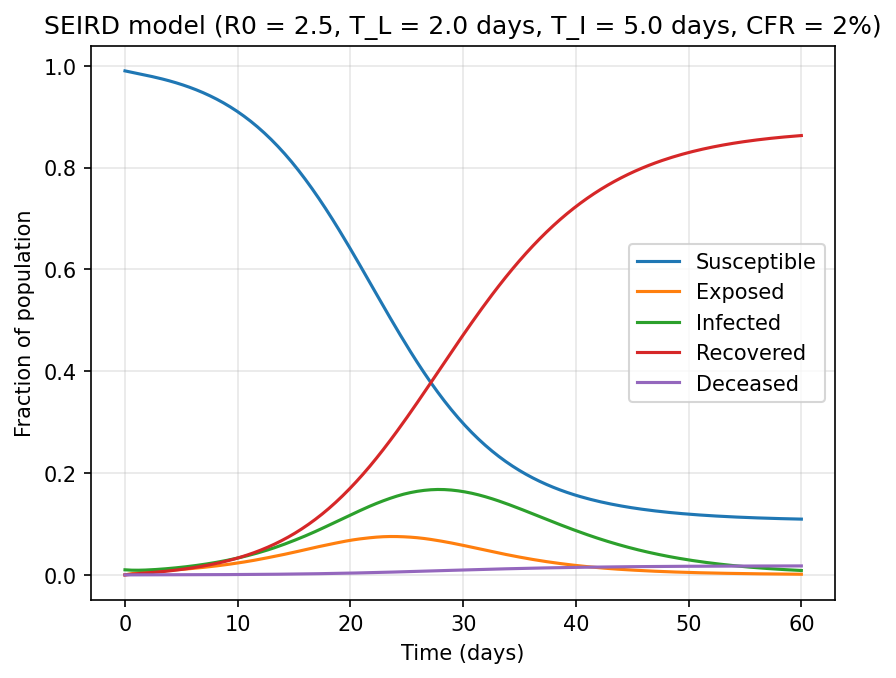

In [7]:
# Extract results
y = solution.y  # shape (5, len(t_eval))

# ------------------------------
# 4. Plot results
# ------------------------------
plt.figure(dpi=150)
plt.plot(t_eval, y.T)
plt.title(f'SEIRD model (R0 = {R0_val}, T_L = {T_L_val} days, T_I = {T_I_val} days, CFR = {CFR_val:.0%})')
plt.xlabel('Time (days)')
plt.ylabel('Fraction of population')
plt.legend(['Susceptible', 'Exposed', 'Infected', 'Recovered', 'Deceased'])
plt.grid(alpha=0.3)
plt.show()

### 2.4: Exercise #2: Burgers equation

We need now to solve the Burgers equation using the Finite Difference Method
$$
    \begin{split}
            \partial_t u(t,x) + u(t,x) \partial_x u(t,x) - \nu^2 \partial_x^2 u(t,x) &= 0 \,,   \qquad \quad \quad (t,x) \in [0, 1]\times [-1, +1], \\
            u(t=0, x) &= - \sin (\pi x)\,,   \;  x \in [-1, +1], \\
            u(t, x=\pm1)&= 0\, ,   \qquad \qquad  t\in[0,1],
    \end{split}
$$
Where $\nu=0.01/\pi$ .

#### Solution:

In [221]:
import numpy as np

use_cfl = False

# Parameters
nu = 0.01 / np.pi          # viscosity
Nx = 201                   # number of spatial points
Nt = 5000                  # number of time steps
xmin, xmax = -1.0, 1.0
tmax = 1.0

# Grid
x = np.linspace(xmin, xmax, Nx)
dx = x[1] - x[0]
dt = tmax / Nt

# Optionally: choose dt using a crude Courant-Friedrichs-Lewy (CFL) condition-like restriction instead
if use_cfl:
    cfl_adv = 0.4
    cfl_dif = 0.4
    dt = min(cfl_adv * dx / np.pi, cfl_dif * dx**2 / nu)   # since |u| <= 1 from initial data
    Nt = int(tmax / dt)

# Initial condition: u(0,x) = -sin(pi x)
u = np.zeros([Nt, Nx])
u[0, :] = - np.sin(np.pi * x)

# Enforce boundary conditions at t = 0
u[:,  0] = 0.0
u[:, -1] = 0.0

# Time stepping: forward Euler in time, central differences in space
for n in tqdm.tqdm( range(1, Nt) ):
    un = u[n-1,:].copy()
    # First derivative u_x (central difference)
    ux = (un[2:] - un[:-2]) / (2.0 * dx)
    # Second derivative u_xx (central difference)
    uxx = (un[2:] - 2.0 * un[1:-1] + un[:-2]) / dx**2
    # Interior update: u_t = -u u_x + nu u_xx
    u[n, 1:-1] = un[1:-1] + dt * (-un[1:-1] * ux + nu * uxx)
    # Dirichlet boundary conditions u(t, ±1) = 0
    u[:, 0 ] = 0.0
    u[:, -1] = 0.0


100%|██████████| 4999/4999 [00:00<00:00, 43081.92it/s]


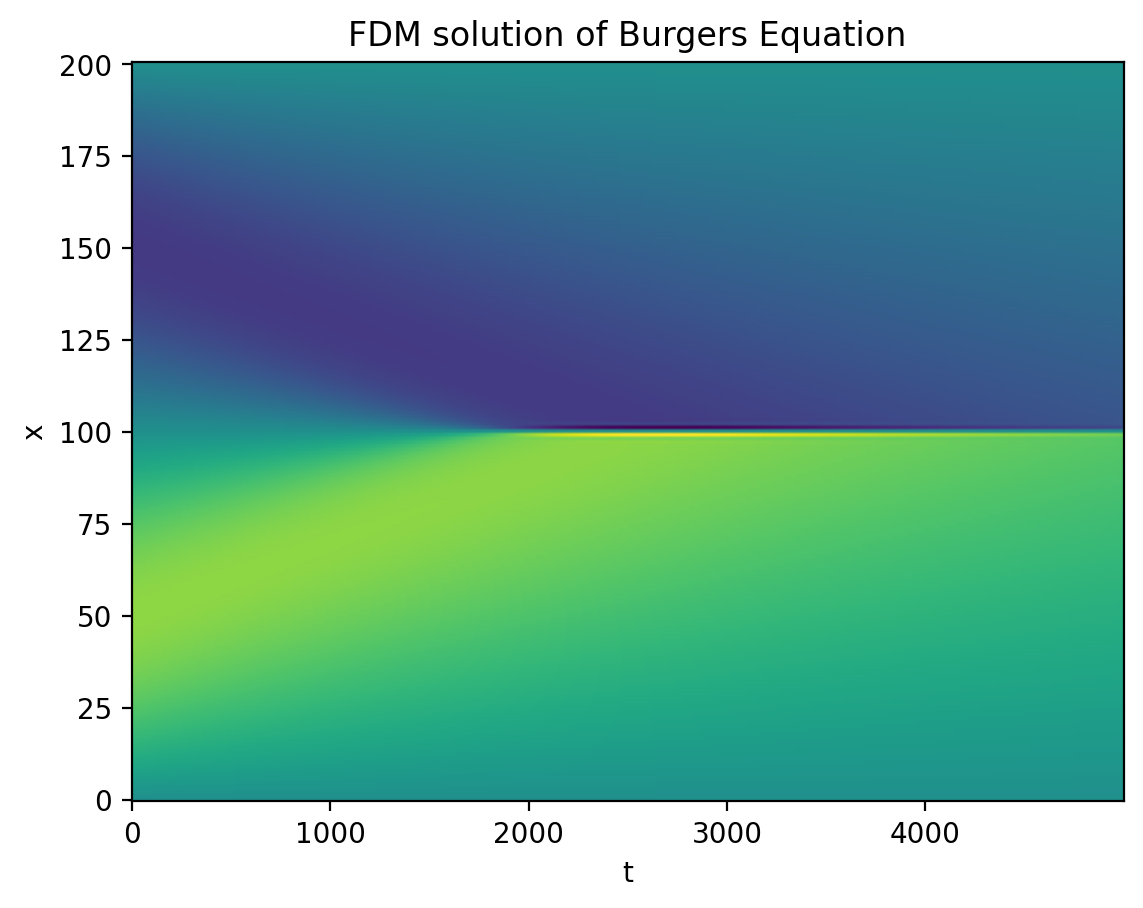

In [222]:
plt.figure(dpi=200)
plt.imshow(u.T, aspect="auto", origin='lower')
plt.title(f"FDM solution of Burgers Equation")
plt.xlabel('t')
plt.ylabel('x')
plt.show()

In [224]:
np.savez_compressed(
    './burgers_sol.npz',
    u=u,
    t=np.linspace(0., tmax, Nt),
    x=x,
    nu=nu
)